# Homogeneous Square Domain

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import pu239, research_reactor
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig

tn.set_default_dtype(tn.float64)
tn.set_num_threads(14)

In [2]:
# Discretization
num_nodes = 256
num_ordinates = 1024

# Get XS data
xs_server = pu239(num_groups=2)

## Vacuum Boundary Conditions

In [3]:
# Create NURBS geometry
length = 6.5 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patches = {cad.bilinear(points): "Pu-239"}

# Create mesh
mesh = IGAMesh(patches)

# Refine mesh resolution
mesh.refine(0, factor=7, degree=3)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()

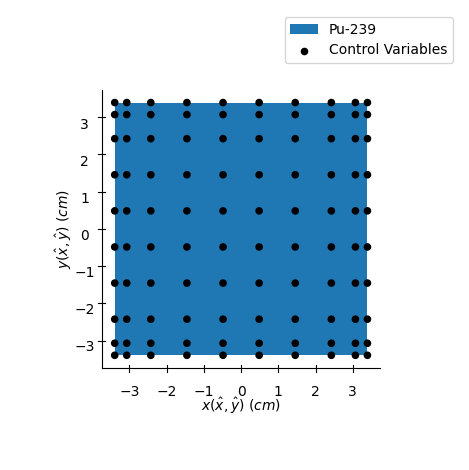

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.legend()
plt.tight_layout()
plt.savefig("./figs/square_vac.png", dpi=300)
plt.show()

In [5]:
# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H, S, F, _, B_out = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info_vac.csv")

Discretization: N = 1024, G = 2, P = 1, A = 10, B = 10
Assembling Patch 1
Step            Ranks                     Compression  Elapsed Time (s)
J               1,1,1,1,1,1                  1475.76        0.83
J_det           1,1,1                          35.64        1.59
R               5,25,20,16,4                    2.81        1.93
dR              5,25,35,24,7,2                  2.95        1.93
J_detRT         5,25,20,16,4                    2.81        1.97
JdR             5,25,35,24,7,2                  2.95        1.98
Intg_int        1                              50.00        2.43
Intg_str        2,2                            33.11        2.43
H               3,3,3,3,3,5                  8801.03        2.43
S               1,1,1,1,1,1               57221064.12        2.43
F               1,1,1,1,1,1               57221064.12        2.43
Jx_det_in       1,1                             4.31        2.69
Jy_det_in       1,1                             4.31        2.69
Rx_in  

In [6]:
k, psi = eig(
    LHS=LinearOperator([H, B_out, -S], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration
-- (0): k = 0.94088332, Angular Flux L2-Error = 0.60045681, Elapsed Time = 2.496
-- (1): k = 0.97956151, Angular Flux L2-Error = 0.13167592, Elapsed Time = 4.918
-- (2): k = 0.99157623, Angular Flux L2-Error = 0.0435532, Elapsed Time = 7.399
-- (3): k = 0.99562046, Angular Flux L2-Error = 0.0154507, Elapsed Time = 9.91
-- (4): k = 0.99704023, Angular Flux L2-Error = 0.00561279, Elapsed Time = 12.261
-- (5): k = 0.99754987, Angular Flux L2-Error = 0.00205845, Elapsed Time = 14.903
-- (6): k = 0.9977351, Angular Flux L2-Error = 0.000758, Elapsed Time = 17.357
-- (7): k = 0.99780289, Angular Flux L2-Error = 0.00027967, Elapsed Time = 19.93
-- (8): k = 0.99782781, Angular Flux L2-Error = 0.00010329, Elapsed Time = 22.605
-- (9): k = 0.99783699, Angular Flux L2-Error = 3.817e-05, Elapsed Time = 25.326
-- (10): k = 0.99784038, Angular Flux L2-Error = 1.411e-05, Elapsed Time = 27.809
-- (11): k = 0.99784163, Angular Flux L2-Error = 5.22e-06, Elapsed Time = 30.551
-- (

In [7]:
# Get OpenMC solution
k_mc = [0.997955, 0.000031]
phi_mc = np.load("./openmc/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

keff error: -11.264142826794554 +/- 3.1e-05 pcm


<Figure size 640x480 with 0 Axes>

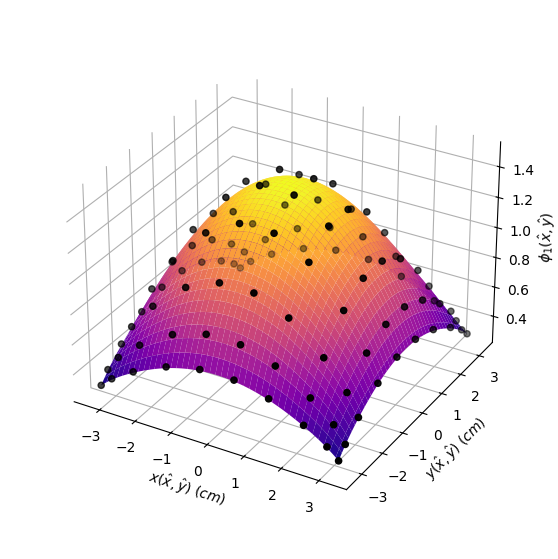

<Figure size 640x480 with 0 Axes>

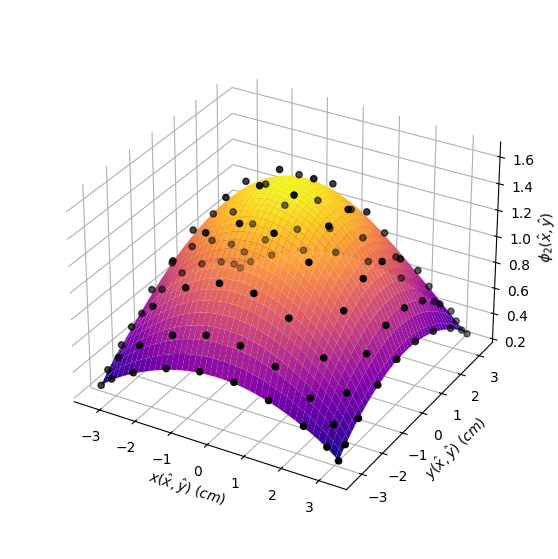

Scalar flux Relative L2-error (g = 1): 0.0016650298611775773
Scalar flux Relative L2-error (g = 2): 0.001716296792934663
Total scalar flux Relative L2-error: 0.0016925649860361105


In [8]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(2, 2))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_2d=False, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.savefig(f"./figs/phi_{g + 1}_vac.png", dpi=300)
    plt.show()

# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

for g in range(xs_server.num_groups):
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)

## Reflective Boundary Conditions

In [9]:
# Create NURBS geometry
length = 3.591204 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patches = {cad.bilinear(points): "Pu-239"}

# Create mesh
mesh = IGAMesh(patches)

# Refine mesh resolution
mesh.refine(0, factor=[3, 9], degree=3)

# Connect mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_condition(("top", "bottom"))

# Finalize patches
mesh.finalize()

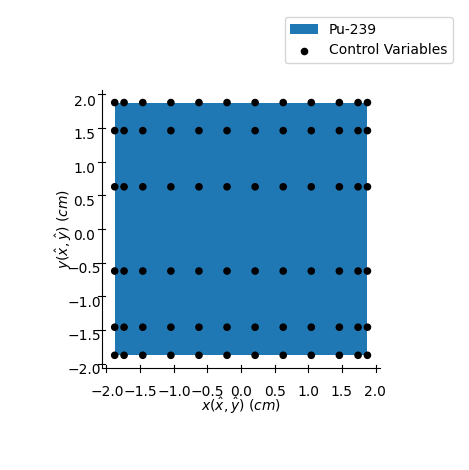

In [10]:
# Plot final mesh
ax = mesh.plot()
plt.legend()
plt.tight_layout()
plt.savefig("./figs/square_ref.png", dpi=300)
plt.show()

In [11]:
# Initialize builder
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)

# Set builder settings
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H, S, F, B_in, B_out = assembler.build(use_tt=True)

# Save TT information
assembler.save_tt_info("./tt_info_ref.csv")

Discretization: N = 1024, G = 2, P = 1, A = 6, B = 12
Assembling Patch 1
Step            Ranks                     Compression  Elapsed Time (s)
J               1,1,1,1,1,1                   864.00        0.47
J_det           1,1,1                          21.60        0.86
R               3,15,12,16,4                    3.18        1.00
dR              3,15,21,24,7,2                  3.13        1.00
J_detRT         3,15,12,16,4                    3.18        1.01
JdR             3,15,21,24,7,2                  3.13        1.03
Intg_int        1                              28.80        1.31
Intg_str        2,2                            15.90        1.31
H               3,3,3,3,3,5                  6689.88        1.31
S               1,1,1,1,1,1               30495472.56        1.31
F               1,1,1,1,1,1               30495472.56        1.31
Jx_det_in       1,1                             2.67        1.46
Jy_det_in       1,1                             4.80        1.46
Rx_in   

In [12]:
k, psi = eig(
    LHS=LinearOperator([H, B_out, -S, -B_in], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

# Calculate eigenvalue error
print("keff error: {} pcm".format((k - 1) * 1e5))

Starting power iteration
-- (0): k = 0.98268504, Angular Flux L2-Error = 0.54817231, Elapsed Time = 2.336
-- (1): k = 0.99635355, Angular Flux L2-Error = 0.05197729, Elapsed Time = 4.676
-- (2): k = 0.9988636, Angular Flux L2-Error = 0.01036889, Elapsed Time = 6.986
-- (3): k = 0.99937129, Angular Flux L2-Error = 0.00219924, Elapsed Time = 9.245
-- (4): k = 0.99947805, Angular Flux L2-Error = 0.00047483, Elapsed Time = 11.522
-- (5): k = 0.9995009, Angular Flux L2-Error = 0.00010381, Elapsed Time = 13.775
-- (6): k = 0.99950583, Angular Flux L2-Error = 2.39e-05, Elapsed Time = 16.076
-- (7): k = 0.9995069, Angular Flux L2-Error = 6.81e-06, Elapsed Time = 18.551
-- (8): k = 0.99950713, Angular Flux L2-Error = 2.81e-06, Elapsed Time = 20.86
-- (9): k = 0.99950718, Angular Flux L2-Error = 1.75e-06, Elapsed Time = 23.087
-- (10): k = 0.99950719, Angular Flux L2-Error = 1.09e-06, Elapsed Time = 25.469
-- (11): k = 0.99950719, Angular Flux L2-Error = 7.2e-07, Elapsed Time = 27.689
-- (12): k

<Figure size 640x480 with 0 Axes>

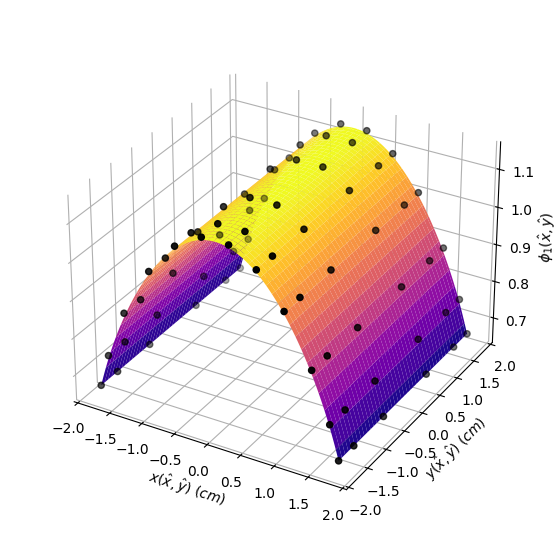

<Figure size 640x480 with 0 Axes>

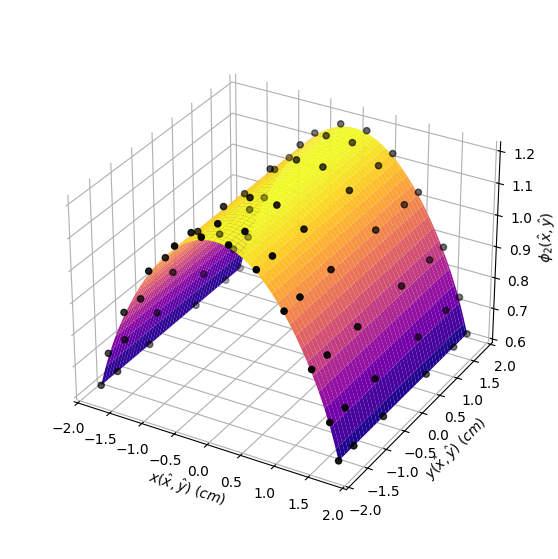

In [13]:
# Iterate through groups and plot
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_2d=False, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.savefig(f"./figs/phi_{g + 1}_ref.png", dpi=300)
    plt.show()

## Linearly Anisotropic

In [14]:
# Get XS data
xs_server = research_reactor(is_anisotropic=True)

# Create NURBS geometry
length = 9.4959 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patches = {cad.bilinear(points): "Research Reactor"}

# Create mesh
mesh = IGAMesh(patches)

# Refine mesh resolution
mesh.refine(0, factor=[5, 7], degree=3)

# Connect patches
mesh.connect()

# Define boundary conditions
mesh.set_reflective_condition(("left", "top", "bottom"))

# Finalize mesh
mesh.finalize()

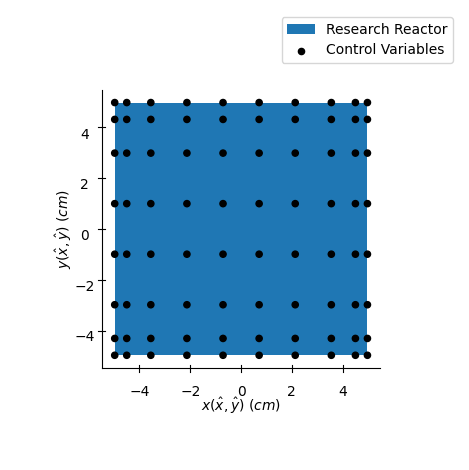

In [15]:
# Plot final mesh
ax = mesh.plot()
plt.legend()
plt.tight_layout()
plt.savefig("./figs/square_anisotropic.png", dpi=300)
plt.show()

In [16]:
# Initialize builder
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)

# Set builder settings
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H, S, F, B_in, B_out = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info_anisotropic.csv")

Discretization: N = 1024, G = 2, P = 1, A = 8, B = 10
Assembling Patch 1
Step            Ranks                     Compression  Elapsed Time (s)
J               1,1,1,1,1,1                  1120.00        0.53
J_det           1,1,1                          28.00        1.05
R               5,25,20,16,4                    2.01        1.26
dR              5,25,35,24,7,2                  2.11        1.26
J_detRT         5,25,20,16,4                    2.01        1.27
JdR             5,25,35,24,7,2                  2.11        1.28
Intg_int        1                              39.02        1.68
Intg_str        2,2                            24.06        1.68
H               3,3,3,3,3,5                  7334.75        1.68
S               3,3,2,1,1,1               6610082.64        1.68
F               1,1,1,1,1,1               38512977.91        1.68
Jx_det_in       1,1                             3.64        1.86
Jy_det_in       1,1                             4.31        1.86
Rx_in    

In [17]:
k, psi = eig(
    LHS=LinearOperator([H, B_out, -S, -B_in], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

# Calculate eigenvalue error
print("keff error: {} pcm".format((k - 1) * 1e5))

Starting power iteration
-- (0): k = 0.9043517, Angular Flux L2-Error = 1.21615946, Elapsed Time = 2.539
-- (1): k = 0.98619096, Angular Flux L2-Error = 0.1402703, Elapsed Time = 4.965
-- (2): k = 0.99748486, Angular Flux L2-Error = 0.02174288, Elapsed Time = 7.386
-- (3): k = 0.99949277, Angular Flux L2-Error = 0.00405318, Elapsed Time = 9.79
-- (4): k = 0.99987126, Angular Flux L2-Error = 0.0007757, Elapsed Time = 12.243
-- (5): k = 0.99994376, Angular Flux L2-Error = 0.00014928, Elapsed Time = 14.701
-- (6): k = 0.99995771, Angular Flux L2-Error = 2.877e-05, Elapsed Time = 17.086
-- (7): k = 0.9999604, Angular Flux L2-Error = 5.55e-06, Elapsed Time = 19.065
-- (8): k = 0.99996092, Angular Flux L2-Error = 1.07e-06, Elapsed Time = 20.424
-- (9): k = 0.99996102, Angular Flux L2-Error = 2.1e-07, Elapsed Time = 21.43
-- (10): k = 0.99996104, Angular Flux L2-Error = 4e-08, Elapsed Time = 22.016
-- (11): k = 0.99996104, Angular Flux L2-Error = 1e-08, Elapsed Time = 22.396
-- Converged: k =

<Figure size 640x480 with 0 Axes>

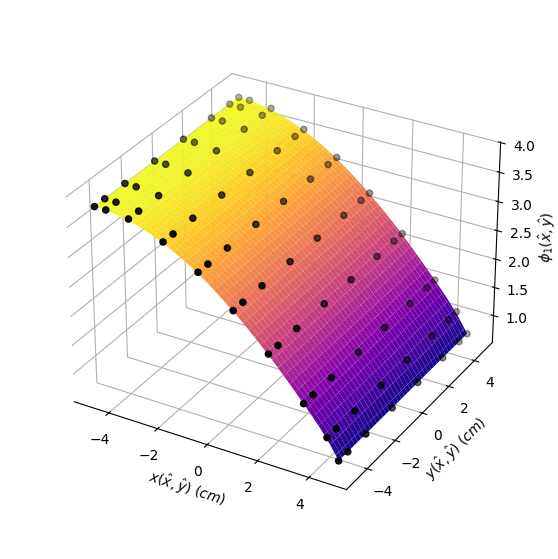

<Figure size 640x480 with 0 Axes>

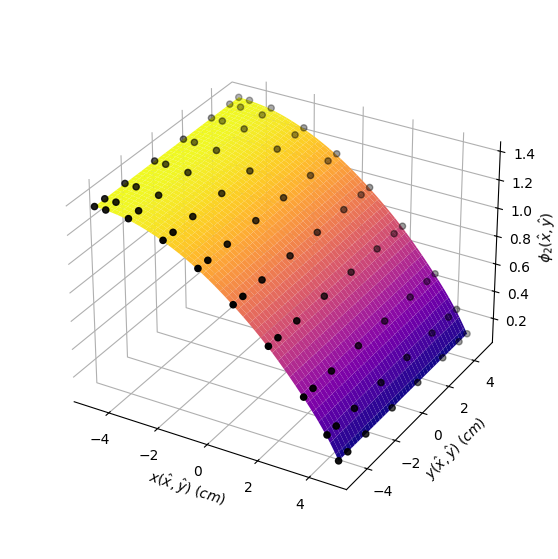

In [18]:
# Iterate through groups and plot
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_2d=False, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.savefig(f"./figs/phi_{g + 1}_anisotropic.png", dpi=300)
    plt.show()